# **Импорты**

In [ ]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import gc

# Библиотеки глубокого обучения
import gdown
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.layers import AveragePooling2D, Concatenate, UpSampling2D, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K

# Настройка стилей графиков
import seaborn as sns
sns.set_style('darkgrid')

# Проверка конфигурации оборудования
print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU устройства:", tf.config.list_physical_devices('GPU'))

Версия TensorFlow: 2.20.0
Доступные GPU устройства: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Получение данных**

In [ ]:
# Загрузка архива из облачного хранилища Яндекс
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)

# Распаковка файлов в фоновом режиме (скрывая громоздкий лог распаковки)
!unzip -qo construction_256x192.zip
print("Архив успешно распакован. Директории 'train/' и 'val/' созданы на диске.")

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:11<00:00, 18.3MB/s]


Архив успешно распакован. Директории 'train/' и 'val/' созданы на диске.


# **Параметры модели**

In [ ]:
# Параметры геометрии изображений базы и классов
IMG_HEIGHT = 256
IMG_WIDTH = 192
NUM_CLASSES = 7
TRAIN_DIRECTORY = 'train'
VAL_DIRECTORY = 'val'

# Оригинальные цвета пикселей (16 классов исходного датасета)
FLOOR = (100, 100, 100); CEILING = (0, 0, 100); WALL = (0, 100, 0); COLUMN = (100, 0, 0)
APERTURE = (0, 100, 100); DOOR = (100, 0, 100); WINDOW = (100, 100, 0); EXTERNAL = (200, 200, 200)
RAILINGS = (0, 200, 0); BATTERY = (200, 0, 0); PEOPLE = (0, 200, 200); LADDER = (0, 0, 200)
INVENTORY = (200, 0, 200); LAMP = (200, 200, 0); WIRE = (0, 100, 200); BEAM = (100, 0, 200)

def rgb_to_7_labels(image_list):
    result = []
    for img in image_list:
        sample = np.array(img)
        # Компактный формат uint8 (1 канал вместо 7 каналов One-Hot) экономит до 85% ОЗУ
        y = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype='uint8')

        # 0 класс - FLOOR
        y[np.where(np.all(sample == FLOOR, axis=-1))] = 0
        # 1 класс - CEILING
        y[np.where(np.all(sample == CEILING, axis=-1))] = 1
        # 2 класс - WALL
        y[np.where(np.all(sample == WALL, axis=-1))] = 2
        # 3 класс - APERTURE, DOOR, WINDOW
        for cl in [APERTURE, DOOR, WINDOW]:
            y[np.where(np.all(sample == cl, axis=-1))] = 3
        # 4 класс - COLUMN, RAILINGS, LADDER
        for cl in [COLUMN, RAILINGS, LADDER]:
            y[np.where(np.all(sample == cl, axis=-1))] = 4
        # 5 класс - INVENTORY
        y[np.where(np.all(sample == INVENTORY, axis=-1))] = 5
        # 6 класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE
        for cl in [LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE]:
            y[np.where(np.all(sample == cl, axis=-1))] = 6

        result.append(y)
    return np.array(result)

def load_images_from_folder(base_path, sub_folder):
    full_path = os.path.join(base_path, sub_folder)
    return [image.load_img(os.path.join(full_path, f), target_size=(IMG_HEIGHT, IMG_WIDTH)) for f in sorted(os.listdir(full_path))]

print("Шаг 1: Чтение и нормализация оригинальных снимков...")
tmp_train_img = load_images_from_folder(TRAIN_DIRECTORY, 'original')
tmp_val_img = load_images_from_folder(VAL_DIRECTORY, 'original')

x_train = np.array([image.img_to_array(img) for img in tmp_train_img], dtype='float32') / 255.0
x_val = np.array([image.img_to_array(img) for img in tmp_val_img], dtype='float32') / 255.0

# Моментально освобождаем память от тяжелых PIL объектов оригиналов
del tmp_train_img, tmp_val_img
gc.collect()

print("Шаг 2: Чтение и группировка цветных масок в 7 макро-классов...")
tmp_train_seg = load_images_from_folder(TRAIN_DIRECTORY, 'segment')
tmp_val_seg = load_images_from_folder(VAL_DIRECTORY, 'segment')

y_train_sparse = rgb_to_7_labels(tmp_train_seg)
y_val_sparse = rgb_to_7_labels(tmp_val_seg)

# Моментально освобождаем память от PIL объектов масок сегментации
del tmp_train_seg, tmp_val_seg
gc.collect()

print("\n--- ДАННЫЕ УСПЕШНО СФОРМИРОВАНЫ В ОПТИМАЛЬНОМ СПРАВОЧНОМ ВИДЕ ---")
print("Размер обучающего тензора картинок x_train:", x_train.shape)
print("Размер разреженного тензора масок y_train_sparse:", y_train_sparse.shape)

Шаг 1: Чтение и нормализация оригинальных снимков...
Шаг 2: Чтение и группировка цветных масок в 7 макро-классов...

--- ДАННЫЕ УСПЕШНО СФОРМИРОВАНЫ В ОПТИМАЛЬНОМ СПРАВОЧНОМ ВИДЕ ---
Размер обучающего тензора картинок x_train: (1900, 256, 192, 3)
Размер разреженного тензора масок y_train_sparse: (1900, 256, 192, 1)


# **Архитектура сети**

In [ ]:
def build_pspnet(input_shape=(256, 192, 3), num_classes=7):
    inputs = Input(shape=input_shape)

    # --- ЭНКОДЕР (Backbone извлечения базовых признаков) ---
    x = Conv2D(48, (3, 3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(48, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)  # Размер снижается до: 128 x 96

    x = Conv2D(96, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)  # Размер снижается до: 64 x 48

    x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    features = MaxPooling2D((2, 2))(x)  # Итоговая базовая карта признаков: 32 x 24

    feat_h, feat_w = 32, 24  # Фиксируем пространственные размеры для пирамиды

    # --- МОДУЛЬ ПИРАМИДАЛЬНОГО ПУЛИНГА (Pyramid Pooling Module) ---
    # Бин-размеры сеток согласно оригинальной научной статье PSPnet: 1x1, 2x2, 3x3, 6x6
    pool_bins = [1, 2, 3, 6]
    pyramid_outputs = [features] # Первым слоем укладываем исходные мелкозернистые признаки

    for bin_size in pool_bins:
        stride_h = feat_h // bin_size
        stride_w = feat_w // bin_size

        # Шаг 1: Среднее уменьшение разрешения до размеров текущего бина
        pool = AveragePooling2D(pool_size=(stride_h, stride_w),
                                strides=(stride_h, stride_w),
                                padding='same')(features)

        # Шаг 2: Свертка 1х1 уменьшает число каналов до 1/N от исходных
        pool = Conv2D(48, (1, 1), padding='same', activation='relu')(pool)
        pool = BatchNormalization()(pool)

        # Шаг 3: Интерполяция подрешетки обратно к исходному размеру карты признаков (32x24)
        upsampled = Lambda(lambda y: tf.image.resize(y, (feat_h, feat_w)))(pool)
        pyramid_outputs.append(upsampled)

    # Склеиваем по оси каналов базовые признаки и все 4 масштаба подрешеток пирамиды
    x = Concatenate(axis=-1)(pyramid_outputs)

    # --- ДЕКОДЕР (Финальная сборка и масштабирование) ---
    x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Поднимаем разрешение признаковой карты от 32x24 до исходных 256x192 пикселей
    x = Lambda(lambda y: tf.image.resize(y, (input_shape[0], input_shape[1])))(x)

    # Финальный слой пиксельной классификации на 7 выходов
    outputs = Conv2D(num_classes, (1, 1), activation='softmax', padding='same')(x)

    model = Model(inputs=inputs, outputs=outputs, name="PSPNet_Architecture")
    return model

# Иннициализация и вывод структуры сети
model = build_pspnet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES)
model.summary()

Model: "PSPNet_Architecture"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 192,  │      1,344 │ input_layer[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 192,  │        192 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 192,  │     20,784 │ batch_normalizat… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 192,  │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 96,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 96,   │     41,568 │ max_pooling2d[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 96,   │        384 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 48,    │    166,080 │ max_pooling2d_1[… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 48,    │        768 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 24,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 1, 1, 192) │          0 │ max_pooling2d_2[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 2, 2, 192) │          0 │ max_pooling2d_2[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 4, 3, 192) │          0 │ max_pooling2d_2[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_3 │ (None, 7, 6, 192) │          0 │ max_pooling2d_2[… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 1, 1, 48)  │      9,264 │ average_pooling2

 Total params: 934,999 (3.57 MB)

 Trainable params: 933,463 (3.56 MB)

 Non-trainable params: 1,536 (6.00 KB)

# **Обучение**

In [ ]:
# Превентивный жесткий сброс сессии перед тяжелыми вычислениями
K.clear_session()
gc.collect()

# Настраиваем компиляцию под разреженные метки (Sparse)
model.compile(optimizer=Adam(learning_rate=2e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Старт обучения PSPnet на стабильных параметрах ОЗУ...")
start_time = time.time()

# Запуск тренировки модели
history = model.fit(x_train, y_train_sparse,
                    epochs=15,              # 40 эпох оптимально для сходимости архитектуры PSPnet
                    batch_size=8,           # Защита от переполнения ОЗУ / Видеопамяти
                    validation_data=(x_val, y_val_sparse),
                    verbose=1)

print(f"\nПроцесс обучения успешно пройден! Время вычисления: {round((time.time() - start_time)/60, 2)} мин.")

Старт обучения PSPnet на стабильных параметрах ОЗУ...
Epoch 1/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 52s 161ms/step - accuracy: 0.6898 - loss: 0.9497 - val_accuracy: 0.5294 - val_loss: 1.6395
Epoch 2/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.7224 - loss: 0.8191 - val_accuracy: 0.6242 - val_loss: 1.1089
Epoch 3/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.7355 - loss: 0.7660 - val_accuracy: 0.5637 - val_loss: 1.2156
Epoch 4/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.7526 - loss: 0.7130 - val_accuracy: 0.6440 - val_loss: 1.0313
Epoch 5/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.7641 - loss: 0.6792 - val_accuracy: 0.6163 - val_loss: 1.1177
Epoch 6/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.7723 - loss: 0.6569 - val_accuracy: 0.6452 - val_loss: 1.0262
Epoch 7/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.7762 - loss: 0.6404 - val_accuracy: 0.6522 - val_loss: 1.0081
Epoch 8/15
238/238 ━━━━━━━━━━

# **Визуализация**

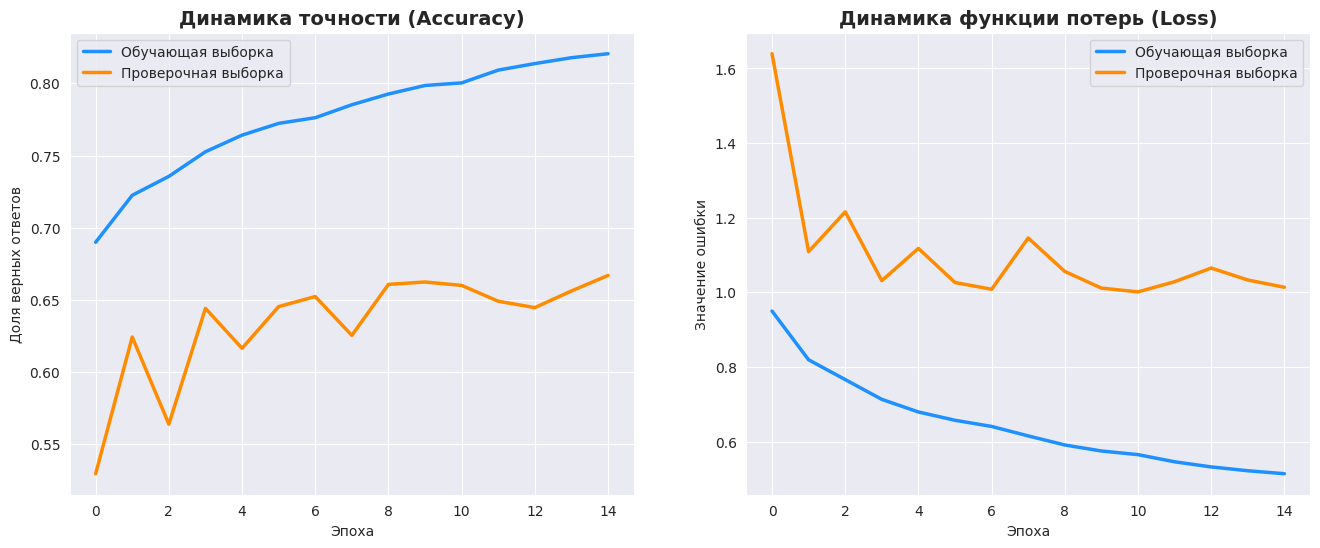

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


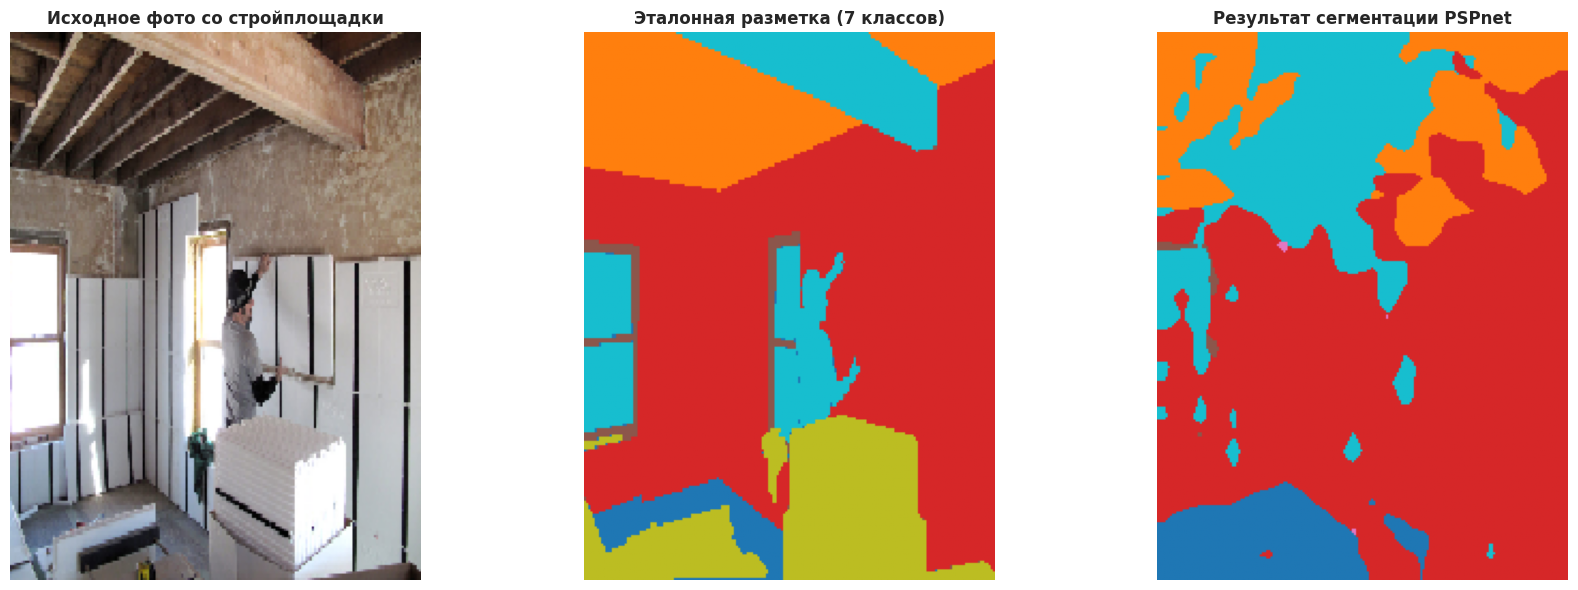

In [ ]:
# 1. Построение графиков обучения за все эпохи
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучающая выборка', color='dodgerblue', linewidth=2.5)
plt.plot(history.history['val_accuracy'], label='Проверочная выборка', color='darkorange', linewidth=2.5)
plt.title('Динамика точности (Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучающая выборка', color='dodgerblue', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Проверочная выборка', color='darkorange', linewidth=2.5)
plt.title('Динамика функции потерь (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Значение ошибки')
plt.legend()
plt.grid(True)
plt.show()


# 2. Визуальная оценка качества сегментации случайного кадра
test_idx = random.randint(0, len(x_val) - 1)

# Получаем вероятности классов от модели (добавляя фейковую пакетную размерность через expand_dims)
raw_prediction = model.predict(np.expand_dims(x_val[test_idx], axis=0))
# Берем индекс максимального аргумента среди 7 каналов
predicted_mask = np.argmax(raw_prediction[0], axis=-1)

# Отрисовка сравнительного окна результатов
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(x_val[test_idx])
axes[0].set_title("Исходное фото со стройплощадки", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(y_val_sparse[test_idx].squeeze(), cmap='tab10')
axes[1].set_title("Эталонная разметка (7 классов)", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(predicted_mask, cmap='tab10')
axes[2].set_title("Результат сегментации PSPnet", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()